# Análisis transcriptómico intestinal de lubina (*Dicentrarchus labrax*)
## TFM — Biomarcadores transcriptómicos de eficiencia digestiva en dorada y lubina
### Autor: Ángel López Francés | Universidad de Murcia

---

**Dataset:** GSE59240 — Calduch-Giner et al. (2016), *Frontiers in Physiology*
- Plataforma: Microarray Agilent de alta densidad (8×15K oligo)
- Organismo: *Dicentrarchus labrax* (lubina europea)
- Tejidos: Intestino **Anterior** (n=8), **Medio** (n=7), **Posterior** (n=5)
- Condición: Peces juveniles en condición basal (sin tratamiento)
- Objetivo: Caracterizar la especialización funcional a lo largo del tracto intestinal

**Referencia:**
Calduch-Giner, J. A., Sitjà-Bobadilla, A., & Pérez-Sánchez, J. (2016). Gene expression profiling reveals functional specialization along the intestinal tract of a carnivorous teleostean fish (*Dicentrarchus labrax*). *Frontiers in Physiology, 7*, 359. https://doi.org/10.3389/fphys.2016.00359

## 1. Instalación de dependencias

In [2]:
!pip install pandas numpy matplotlib seaborn scipy scikit-learn statsmodels

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------- ----------------------- 3.9/9.5 MB 29.4 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 33.0 MB/s  0:00:00

   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [stat

## 2. Importación de librerías

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import f_oneway
from statsmodels.stats.multitest import multipletests
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 150
sns.set_style('whitegrid')

print('Librerías importadas correctamente')

Librerías importadas correctamente


## 3. Carga y preparación de datos

### 3.1 Descripción del formato Agilent

Los archivos de microarray Agilent tienen un formato específico:
- Cabecera con metadatos del escaneado (líneas TYPE, FEPARAMS, DATA, STATS)
- Sección FEATURES con los datos de intensidad por sonda
- Columna `ControlType`: 0 = sonda biológica, 1 = sonda de control (se excluye)
- Columna `gProcessedSignal`: señal de fluorescencia procesada (valor de expresión)
- Columna `SystematicName`: identificador de la sonda/gen

### 3.2 Función de lectura de archivos Agilent

In [15]:
def leer_agilent(path, nombre_muestra):
    # Leer solo las columnas necesarias para ahorrar memoria
    df = pd.read_csv(
        path, sep='\t', comment='*', skiprows=9,
        usecols=['ControlType', 'SystematicName', 'gProcessedSignal'],
        low_memory=False,
        dtype={'gProcessedSignal': 'float32'}
    )
    # Filtrar sondas de control (ControlType != 0)
    df = df[df['ControlType'] == 0][['SystematicName', 'gProcessedSignal']].copy()
    df.columns = ['GeneID', nombre_muestra]
    df = df.dropna()
    # Si hay múltiples sondas por gen, tomar la media
    df = df.groupby('GeneID')[nombre_muestra].mean().reset_index()
    return df


### 3.3 Lectura de todos los archivos y construcción de la matriz

**IMPORTANTE:** Ajusta las rutas a la carpeta donde tienes los archivos descargados de GEO.

In [5]:
# Definir archivos por segmento intestinal
ruta_base = 'c:\\Users\\angel\\Desktop\\datos tfm\\datos lubina\\'  

archivos = {
    # Intestino Anterior (8 muestras)
    'ANT1': ruta_base + 'GSM1431152_ANT1.txt',
    'ANT2': ruta_base + 'GSM1431153_ANT2.txt',
    'ANT3': ruta_base + 'GSM1431154_ANT3.txt',
    'ANT4': ruta_base + 'GSM1431155_ANT4.txt',
    'ANT5': ruta_base + 'GSM1431156_ANT5.txt',
    'ANT6': ruta_base + 'GSM1431157_ANT6.txt',
    'ANT7': ruta_base + 'GSM1431158_ANT7.txt',
    'ANT8': ruta_base + 'GSM1431159_ANT8.txt',
    # Intestino Medio (7 muestras)
    'MED1': ruta_base + 'GSM1431160_MED1.txt',
    'MED2': ruta_base + 'GSM1431161_MED2.txt',
    'MED3': ruta_base + 'GSM1431162_MED3.txt',
    'MED4': ruta_base + 'GSM1431163_MED4.txt',
    'MED5': ruta_base + 'GSM1431164_MED5.txt',
    'MED6': ruta_base + 'GSM1431165_MED6.txt',
    'MED7': ruta_base + 'GSM1431166_MED7.txt',
    # Intestino Posterior (5 muestras)
    'POS1': ruta_base + 'GSM1431167_POS1.txt',
    'POS2': ruta_base + 'GSM1431168_POS2.txt',
    'POS3': ruta_base + 'GSM1431169_POS3.txt',
    'POS4': ruta_base + 'GSM1431170_POS4.txt',
    'POS5': ruta_base + 'GSM1431171_POS5.txt',
}

# Leer y fusionar todos los archivos
dfs = []
for nombre, path in archivos.items():
    df = leer_agilent(path, nombre)
    dfs.append(df)
    print(f'   {nombre}: {len(df):,} sondas')

# Merge por GeneID (inner join: solo sondas presentes en todas las muestras)
matriz = dfs[0]
for df in dfs[1:]:
    matriz = matriz.merge(df, on='GeneID', how='inner')

matriz = matriz.set_index('GeneID')
print(f'\n Matriz final: {matriz.shape[0]:,} genes × {matriz.shape[1]} muestras')
matriz.head()

   ANT1: 14,147 sondas
   ANT2: 14,147 sondas
   ANT3: 14,147 sondas
   ANT4: 14,147 sondas
   ANT5: 14,147 sondas
   ANT6: 14,147 sondas
   ANT7: 14,147 sondas
   ANT8: 14,147 sondas
   MED1: 14,147 sondas
   MED2: 14,147 sondas
   MED3: 14,147 sondas
   MED4: 14,147 sondas
   MED5: 14,147 sondas
   MED6: 14,147 sondas
   MED7: 14,147 sondas
   POS1: 14,147 sondas
   POS2: 14,147 sondas
   POS3: 14,147 sondas
   POS4: 14,147 sondas
   POS5: 14,147 sondas

 Matriz final: 14,147 genes × 20 muestras


,ANT1,ANT2,ANT3,ANT4,ANT5,ANT6,ANT7,ANT8,MED1,MED2,MED3,MED4,MED5,MED6,MED7,POS1,POS2,POS3,POS4,POS5
GeneID,,,,,,,,,,,,,,,,,,,,
L12_14278,1149.561523,2085.927979,2688.648438,2139.147461,1693.711914,2046.910400,3329.179443,2148.349121,1407.476074,2191.760986,2898.426514,2182.745117,1764.623047,6340.150391,969.353577,1159.829102,3102.937500,2151.010010,1634.879517,896.839111
L12_15072,224.776093,384.725830,151.232407,236.961502,203.425262,209.539246,284.102844,436.002502,217.818253,275.792389,259.260803,220.793213,193.940491,314.068420,216.530396,280.366608,426.489502,377.510681,247.743652,329.069855
L12_15957,141.596161,165.554504,136.535858,145.311890,137.958710,137.968658,201.518997,239.964813,119.413101,124.179703,159.538544,129.044098,105.922379,224.360504,210.293549,132.316650,148.939896,167.794952,155.761551,157.939148
L12_17496,36.264893,39.299610,30.542175,33.273491,40.205795,32.954895,36.602421,42.874893,25.021830,27.350290,29.420200,33.825130,23.232441,37.300243,19.380226,27.023945,35.130131,39.176571,21.468254,30.969881
L12_17782,183.136688,174.182312,49.982525,171.943802,135.876953,107.550552,126.158051,130.099106,162.120499,176.157654,110.811905,149.326202,150.354492,341.626740,60.311737,155.048447,126.342102,130.325150,155.786545,116.941254


### 3.4 Definir metadatos de muestras

In [6]:
# Metadatos: asignar segmento intestinal a cada muestra
metadata = pd.DataFrame({
    'Muestra': list(archivos.keys()),
    'Segmento': (['Anterior'] * 8 + ['Medio'] * 7 + ['Posterior'] * 5)
})
metadata = metadata.set_index('Muestra')

# Guardar metadatos
metadata.to_csv('lubina_metadata.csv')
print(metadata)
print('\n Metadatos guardados: lubina_metadata.csv')

          Segmento
Muestra           
ANT1      Anterior
ANT2      Anterior
ANT3      Anterior
ANT4      Anterior
ANT5      Anterior
ANT6      Anterior
ANT7      Anterior
ANT8      Anterior
MED1         Medio
MED2         Medio
MED3         Medio
MED4         Medio
MED5         Medio
MED6         Medio
MED7         Medio
POS1     Posterior
POS2     Posterior
POS3     Posterior
POS4     Posterior
POS5     Posterior

 Metadatos guardados: lubina_metadata.csv


## 4. Normalización

Para microarrays Agilent se aplica transformación **log2** para estabilizar la varianza y normalizar las distribuciones de señal entre arrays.

Los valores negativos o cero se reemplazan por el mínimo positivo antes de log2.

Valores antes de log2: min=0.82, max=637193.81
Valores después de log2: min=-0.28, max=19.28


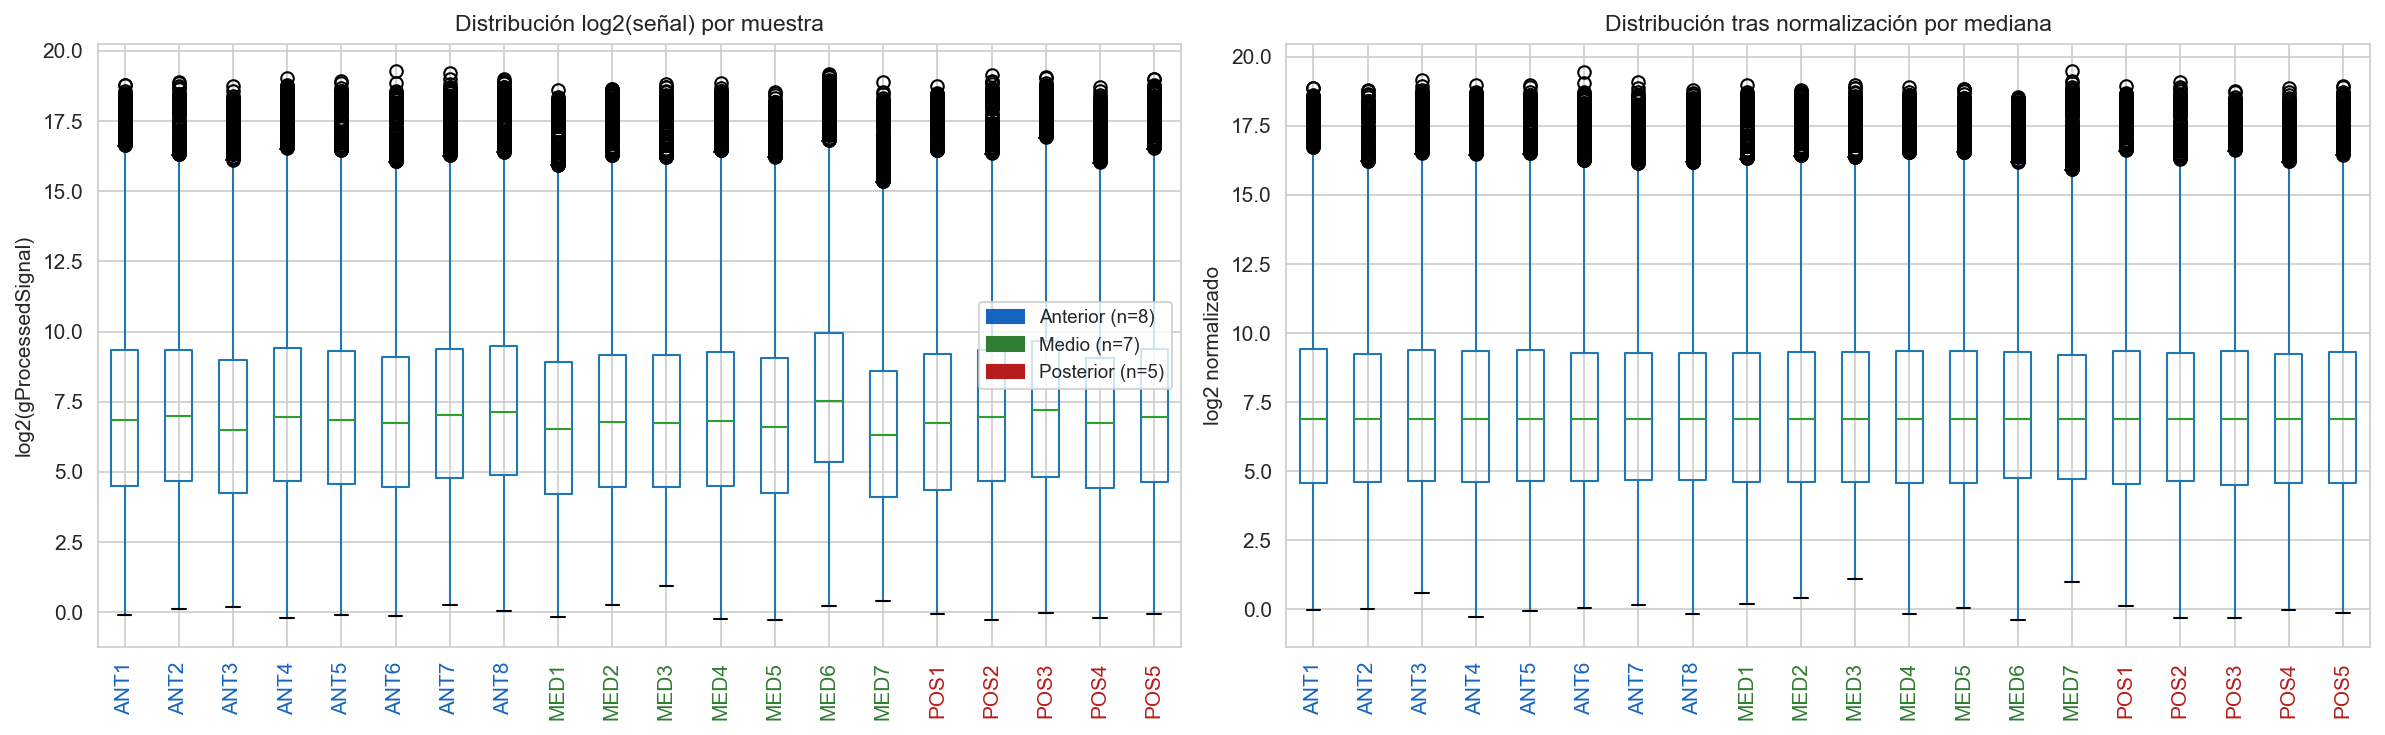

Figura guardada: QC_boxplot_lubina.png


In [7]:
# Reemplazar valores <= 0 con mínimo positivo
min_positivo = matriz[matriz > 0].min().min()
matriz_clean = matriz.clip(lower=min_positivo)

# Transformación log2
log2_matriz = np.log2(matriz_clean)

print(f'Valores antes de log2: min={matriz_clean.min().min():.2f}, max={matriz_clean.max().max():.2f}')
print(f'Valores después de log2: min={log2_matriz.min().min():.2f}, max={log2_matriz.max().max():.2f}')

# Boxplot de normalización
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

colores = ['#1565C0']*8 + ['#2E7D32']*7 + ['#B71C1C']*5

# Sin normalizar
np.log2(matriz_clean).boxplot(ax=axes[0], rot=90)
axes[0].set_title('Distribución log2(señal) por muestra', fontsize=11)
axes[0].set_ylabel('log2(gProcessedSignal)')
for i, tick in enumerate(axes[0].get_xticklabels()):
    tick.set_color(colores[i])

# Normalizado por cuantiles (mediana)
log2_norm = log2_matriz.subtract(log2_matriz.median(axis=0), axis=1)
log2_norm = log2_norm.add(log2_matriz.median(axis=1).mean())
log2_norm.boxplot(ax=axes[1], rot=90)
axes[1].set_title('Distribución tras normalización por mediana', fontsize=11)
axes[1].set_ylabel('log2 normalizado')
for i, tick in enumerate(axes[1].get_xticklabels()):
    tick.set_color(colores[i])

leyenda = [
    mpatches.Patch(color='#1565C0', label='Anterior (n=8)'),
    mpatches.Patch(color='#2E7D32', label='Medio (n=7)'),
    mpatches.Patch(color='#B71C1C', label='Posterior (n=5)')
]
axes[0].legend(handles=leyenda, fontsize=9)

plt.tight_layout()
plt.savefig('QC_boxplot_lubina.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figura guardada: QC_boxplot_lubina.png')

# Usar log2_norm para el resto del análisis
datos = log2_norm.copy()

## 5. Análisis de Componentes Principales (PCA)

El PCA permite visualizar si los tres segmentos intestinales (ANT, MED, POS) presentan perfiles transcriptómicos diferenciados.

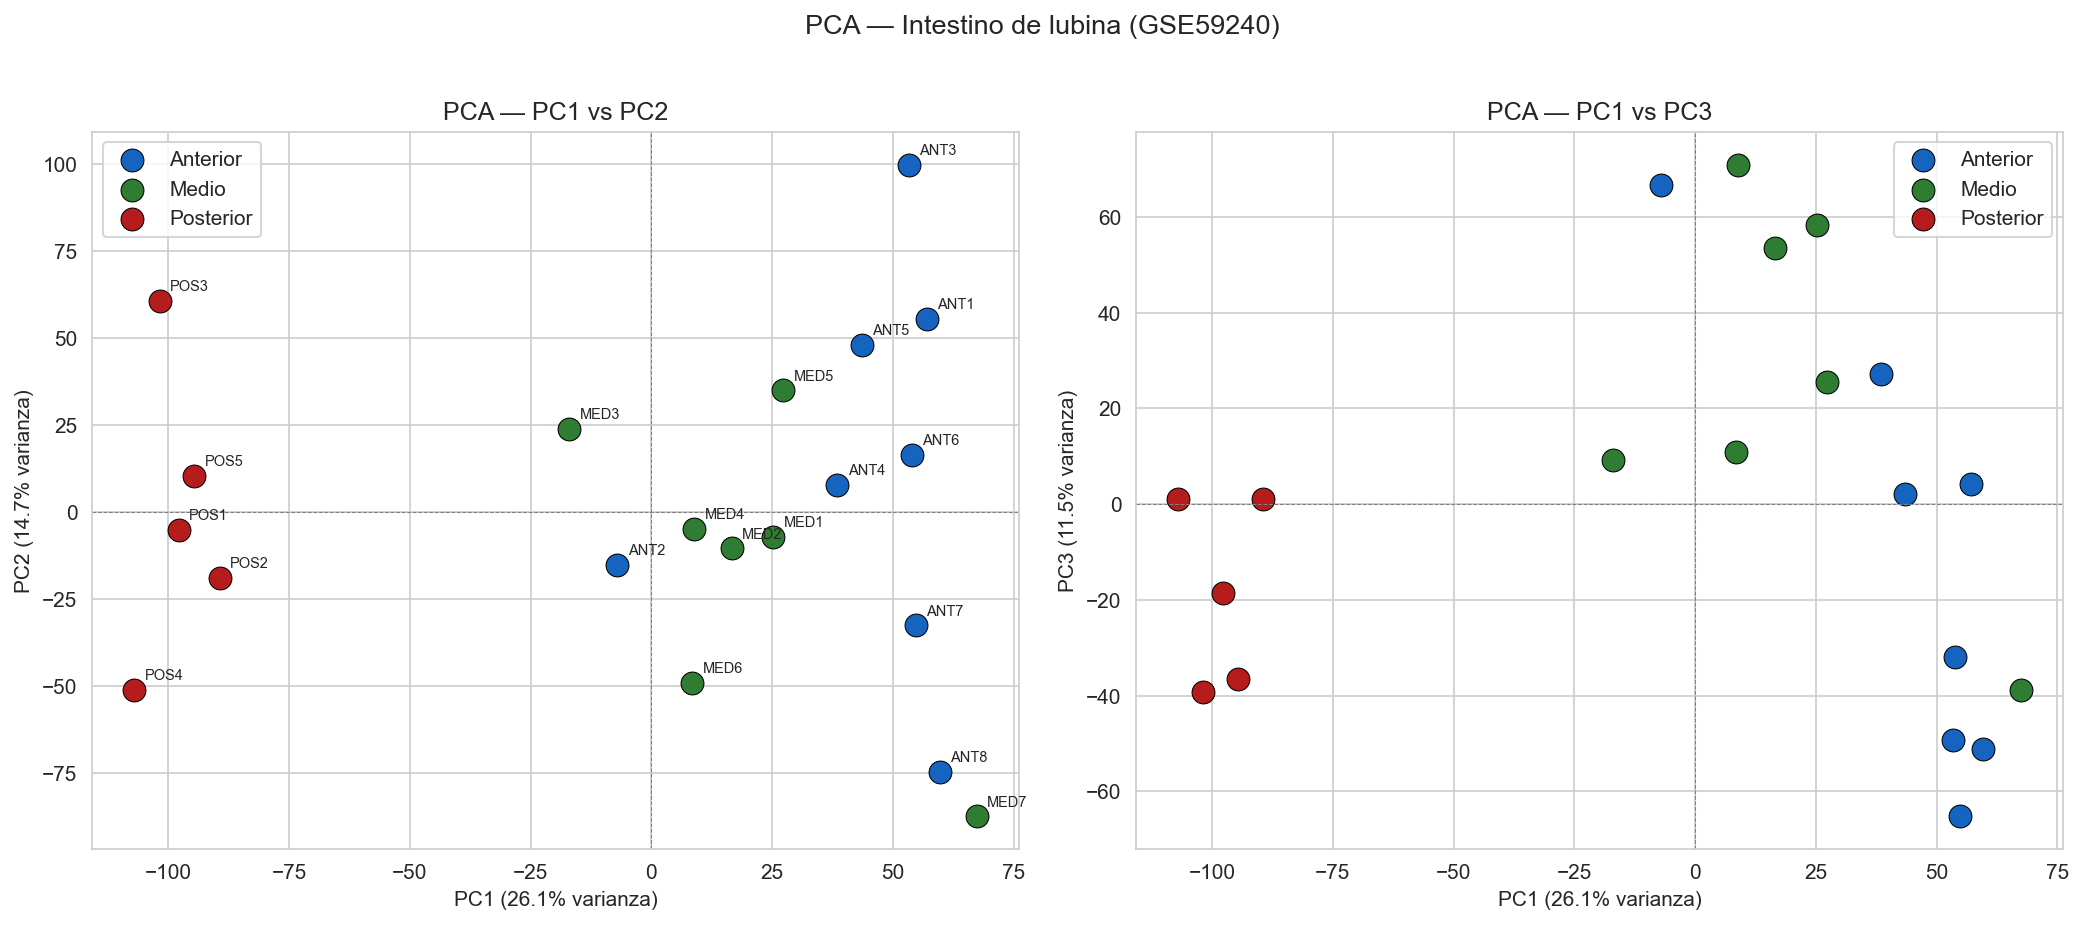

Figura guardada: PCA_lubina.png


In [8]:
# PCA
X = datos.T
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=3)
componentes = pca.fit_transform(X_scaled)
varianza = pca.explained_variance_ratio_ * 100

df_pca = pd.DataFrame(componentes, columns=['PC1','PC2','PC3'], index=datos.columns)
df_pca['Segmento'] = metadata['Segmento']

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colores_seg = {'Anterior': '#1565C0', 'Medio': '#2E7D32', 'Posterior': '#B71C1C'}

for seg, datos_seg in df_pca.groupby('Segmento'):
    axes[0].scatter(datos_seg['PC1'], datos_seg['PC2'],
                    label=seg, color=colores_seg[seg], s=120,
                    edgecolors='black', linewidth=0.5)
    for idx, row in datos_seg.iterrows():
        axes[0].annotate(idx, (row['PC1'], row['PC2']),
                         textcoords='offset points', xytext=(5,5), fontsize=7)

axes[0].set_xlabel(f'PC1 ({varianza[0]:.1f}% varianza)')
axes[0].set_ylabel(f'PC2 ({varianza[1]:.1f}% varianza)')
axes[0].set_title('PCA — PC1 vs PC2', fontsize=12)
axes[0].legend()
axes[0].axhline(0, color='gray', linestyle='--', linewidth=0.5)
axes[0].axvline(0, color='gray', linestyle='--', linewidth=0.5)

for seg, datos_seg in df_pca.groupby('Segmento'):
    axes[1].scatter(datos_seg['PC1'], datos_seg['PC3'],
                    label=seg, color=colores_seg[seg], s=120,
                    edgecolors='black', linewidth=0.5)

axes[1].set_xlabel(f'PC1 ({varianza[0]:.1f}% varianza)')
axes[1].set_ylabel(f'PC3 ({varianza[2]:.1f}% varianza)')
axes[1].set_title('PCA — PC1 vs PC3', fontsize=12)
axes[1].legend()
axes[1].axhline(0, color='gray', linestyle='--', linewidth=0.5)
axes[1].axvline(0, color='gray', linestyle='--', linewidth=0.5)

plt.suptitle('PCA — Intestino de lubina (GSE59240)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('PCA_lubina.png', bbox_inches='tight', dpi=200)
plt.show()
print('Figura guardada: PCA_lubina.png')

## 6. Genes diferencialmente expresados entre segmentos

Se usa **ANOVA de una vía** para identificar genes con expresión significativamente diferente entre los tres segmentos intestinales (ANT vs MED vs POS).

Para microarrays, ANOVA + corrección FDR (Benjamini-Hochberg) es el método estándar cuando no hay grupo control/tratamiento sino comparación entre grupos.

In [9]:
# Separar muestras por segmento
ant_cols = [c for c in datos.columns if c.startswith('ANT')]
med_cols = [c for c in datos.columns if c.startswith('MED')]
pos_cols = [c for c in datos.columns if c.startswith('POS')]

# ANOVA por gen
print('Calculando ANOVA para cada gen...')
pvalores = []
for gen in datos.index:
    ant = datos.loc[gen, ant_cols].values
    med = datos.loc[gen, med_cols].values
    pos = datos.loc[gen, pos_cols].values
    f_stat, p_val = f_oneway(ant, med, pos)
    pvalores.append(p_val)

# Corrección múltiple FDR (Benjamini-Hochberg)
_, padj, _, _ = multipletests(pvalores, method='fdr_bh')

# Calcular medias por segmento
resultados_anova = pd.DataFrame({
    'pvalue': pvalores,
    'padj': padj,
    'media_ANT': datos[ant_cols].mean(axis=1).values,
    'media_MED': datos[med_cols].mean(axis=1).values,
    'media_POS': datos[pos_cols].mean(axis=1).values,
}, index=datos.index)

# Filtrar significativos (FDR < 0.05)
DEGs_lubina = resultados_anova[resultados_anova['padj'] < 0.05].copy()

print(f'\nResultados ANOVA (ANT vs MED vs POS):')
print(f'   Total genes analizados: {len(resultados_anova):,}')
print(f'   Genes significativos (FDR<0.05): {len(DEGs_lubina):,}')

DEGs_lubina.to_csv('DEGs_lubina_intestino.csv')
print('Tabla guardada: DEGs_lubina_intestino.csv')

Calculando ANOVA para cada gen...

Resultados ANOVA (ANT vs MED vs POS):
   Total genes analizados: 14,147
   Genes significativos (FDR<0.05): 4,613
Tabla guardada: DEGs_lubina_intestino.csv


### 6.1 Heatmap de los top 50 genes más variables entre segmentos

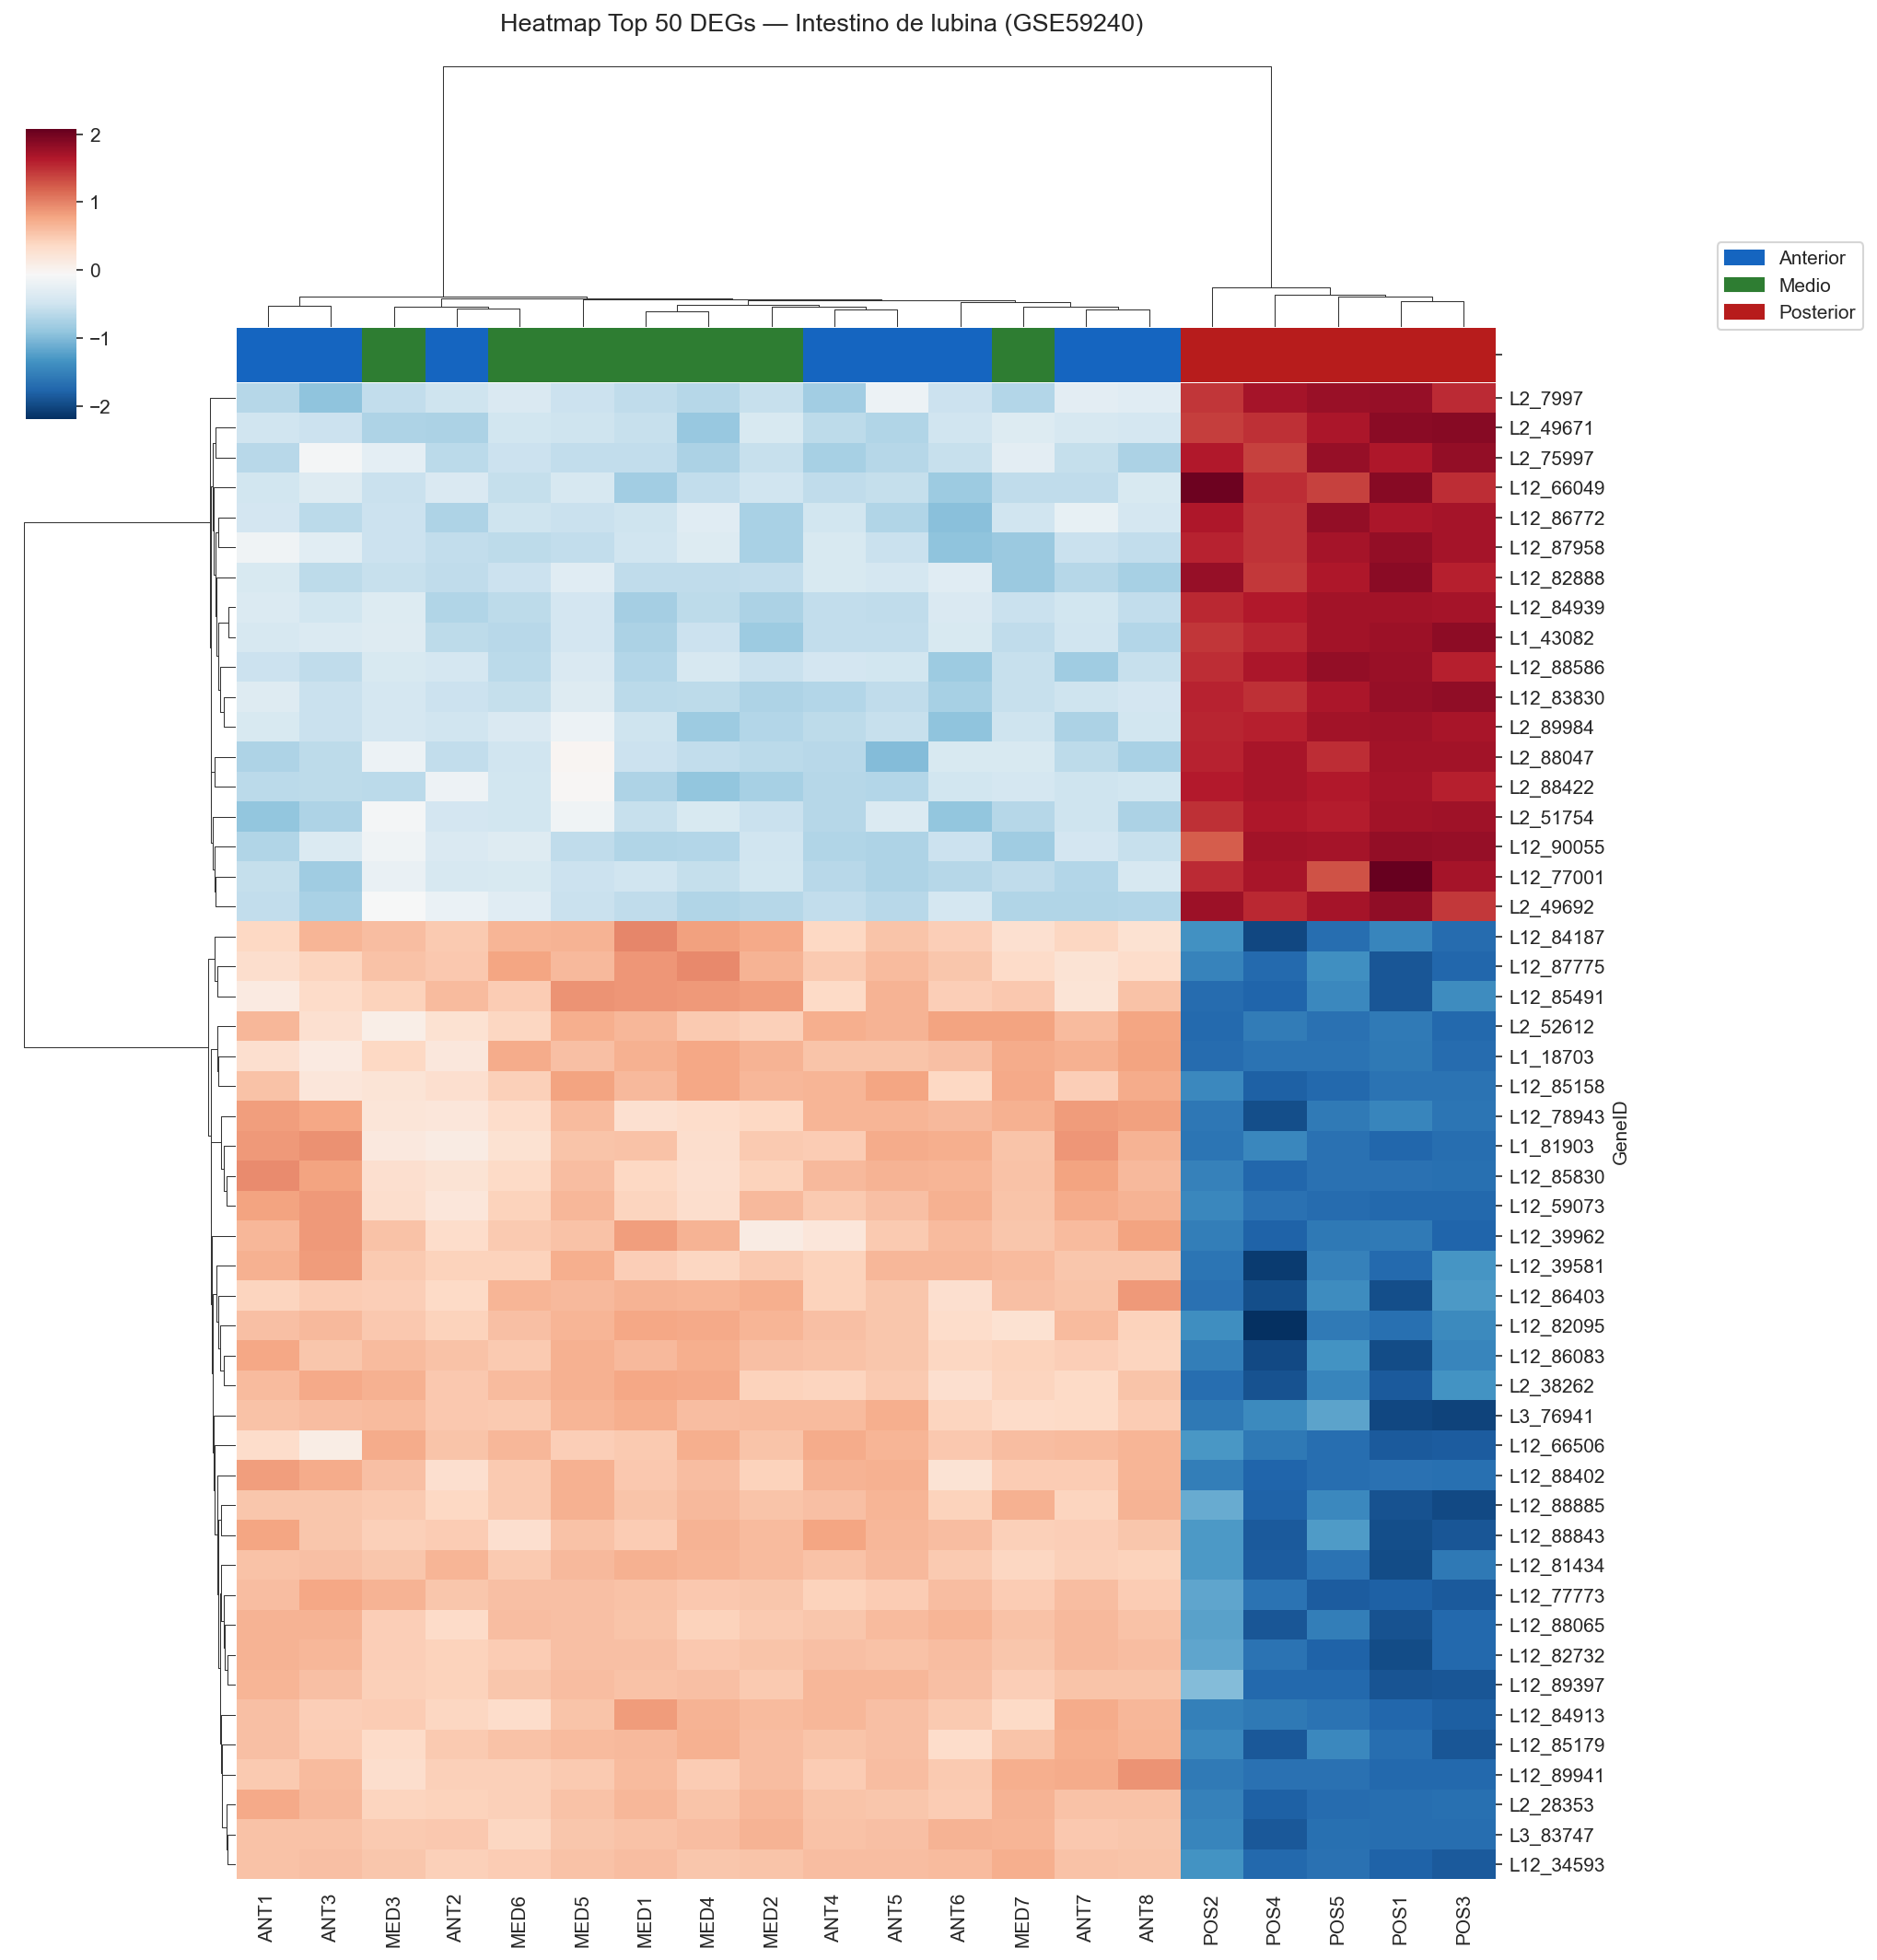

Figura guardada: Heatmap_lubina.png


In [10]:
# Top 50 DEGs por p-valor ajustado
top50 = DEGs_lubina.nsmallest(50, 'padj').index.tolist()
heatmap_data = datos.loc[top50]

# Colores por segmento para barra superior
col_colors = pd.Series(
    ['#1565C0']*8 + ['#2E7D32']*7 + ['#B71C1C']*5,
    index=datos.columns
)

g = sns.clustermap(
    heatmap_data,
    col_colors=col_colors,
    cmap='RdBu_r',
    z_score=0,
    figsize=(12, 14),
    dendrogram_ratio=0.15,
    cbar_pos=(0.02, 0.8, 0.03, 0.15),
    xticklabels=True,
    yticklabels=True,
)
g.fig.suptitle('Heatmap Top 50 DEGs — Intestino de lubina (GSE59240)',
               y=1.01, fontsize=13)

leyenda = [
    mpatches.Patch(color='#1565C0', label='Anterior'),
    mpatches.Patch(color='#2E7D32', label='Medio'),
    mpatches.Patch(color='#B71C1C', label='Posterior')
]
g.ax_heatmap.legend(handles=leyenda, loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.savefig('Heatmap_lubina.png', bbox_inches='tight', dpi=200)
plt.show()
print('Figura guardada: Heatmap_lubina.png')

### 6.2 Perfiles de expresión por segmento — genes digestivos clave

Visualización del gradiente de expresión a lo largo del eje intestinal para genes de interés digestivo.

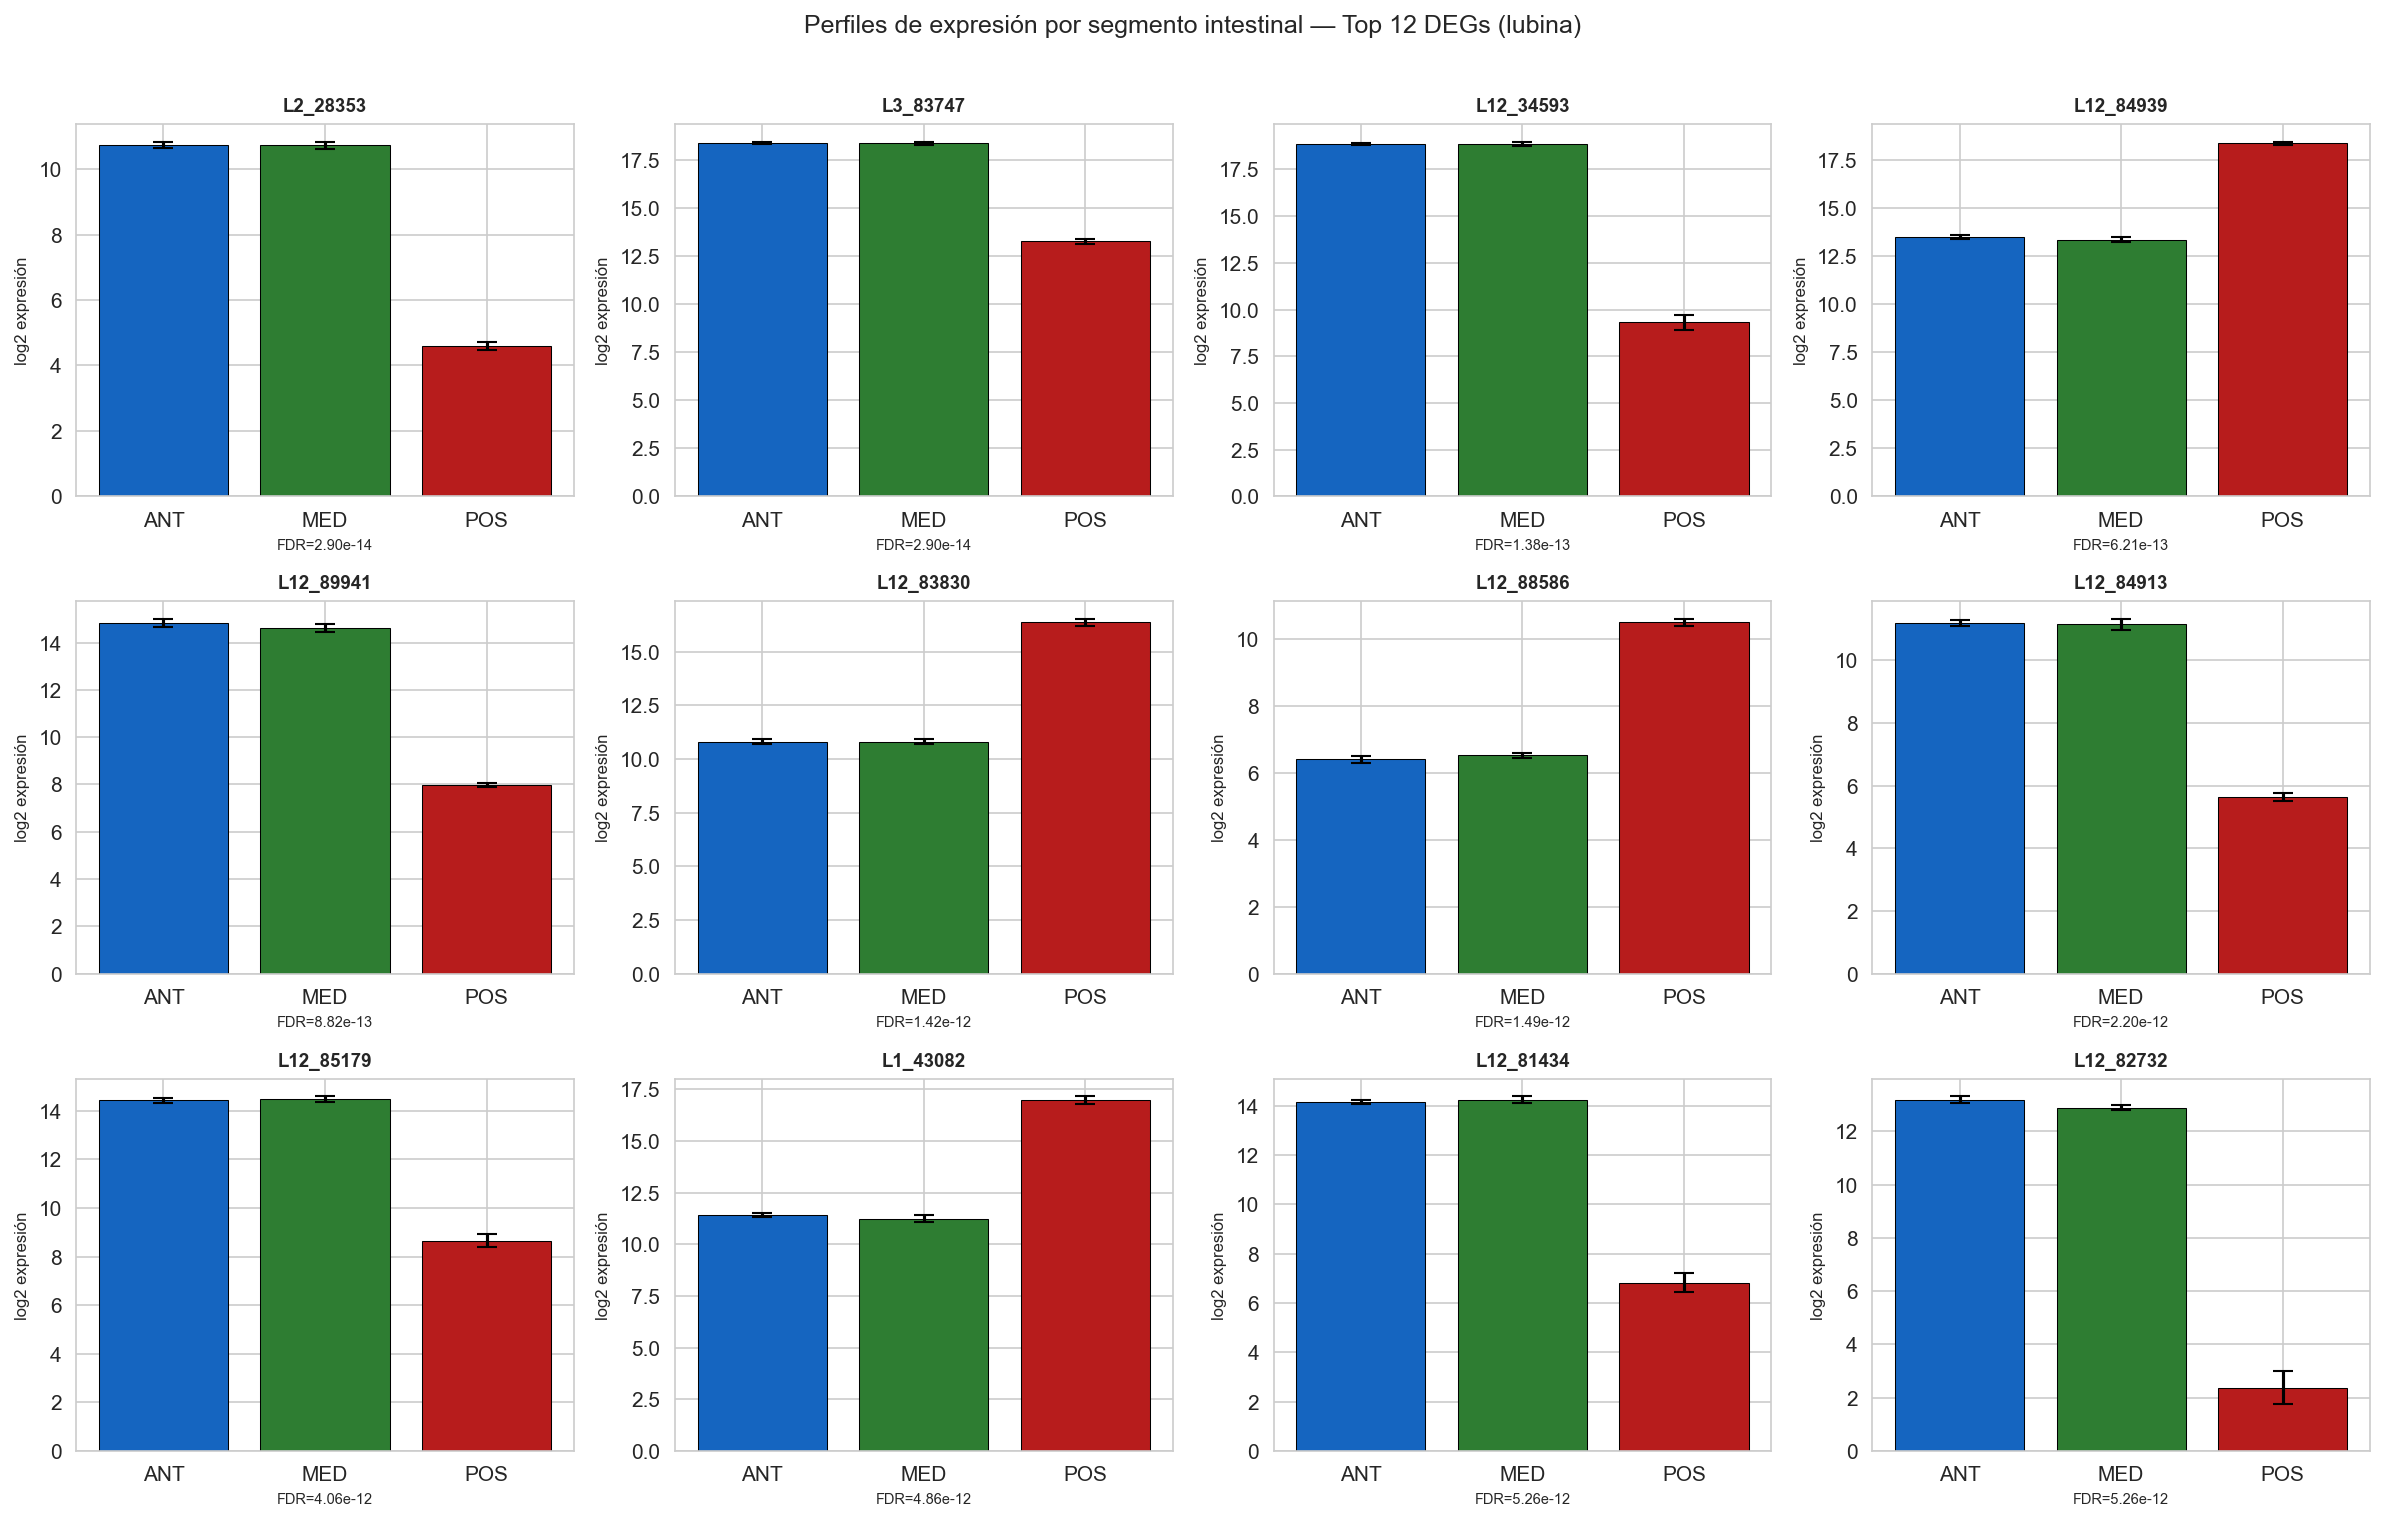

Figura guardada: Perfiles_segmento_lubina.png


In [11]:
# Calcular medias y errores por segmento para todos los DEGs
resumen = pd.DataFrame({
    'ANT_mean': datos[ant_cols].mean(axis=1),
    'ANT_sem':  datos[ant_cols].sem(axis=1),
    'MED_mean': datos[med_cols].mean(axis=1),
    'MED_sem':  datos[med_cols].sem(axis=1),
    'POS_mean': datos[pos_cols].mean(axis=1),
    'POS_sem':  datos[pos_cols].sem(axis=1),
})

# Seleccionar top 12 DEGs para visualización
top12 = DEGs_lubina.nsmallest(12, 'padj').index.tolist()
resumen_top = resumen.loc[top12]

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()
segmentos = ['ANT', 'MED', 'POS']
x = np.arange(3)
colores_seg_list = ['#1565C0', '#2E7D32', '#B71C1C']

for i, gen in enumerate(top12):
    medias = [resumen_top.loc[gen, f'{s}_mean'] for s in segmentos]
    errores = [resumen_top.loc[gen, f'{s}_sem'] for s in segmentos]
    axes[i].bar(x, medias, yerr=errores, color=colores_seg_list,
                capsize=5, edgecolor='black', linewidth=0.5)
    axes[i].set_title(gen, fontsize=9, fontweight='bold')
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(['ANT', 'MED', 'POS'])
    axes[i].set_ylabel('log2 expresión', fontsize=8)
    fdr = DEGs_lubina.loc[gen, 'padj']
    axes[i].set_xlabel(f'FDR={fdr:.2e}', fontsize=7)

plt.suptitle('Perfiles de expresión por segmento intestinal — Top 12 DEGs (lubina)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('Perfiles_segmento_lubina.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figura guardada: Perfiles_segmento_lubina.png')

## 7. Exportar resultados para comparación con dorada

Se exporta la lista de DEGs de lubina para compararla con los DEGs de dorada obtenidos en el notebook `TFM_AngelLopezFrances_Analisis.ipynb`.

In [14]:

DEGs_lubina_ordenados = DEGs_lubina.sort_values('padj')
DEGs_lubina_ordenados.to_csv('DEGs_lubina_intestino.csv')


datos.to_csv('lubina_intestine_normalized.csv')

print('Archivos exportados:')
print(f'  DEGs_lubina_intestino.csv — {len(DEGs_lubina_ordenados):,} DEGs con FDR<0.05')
print(f'  lubina_intestine_normalized.csv — matriz normalizada para iDEP/KEGG')
print(f'\nTop 20 DEGs:')
print(DEGs_lubina_ordenados[['pvalue','padj','media_ANT','media_MED','media_POS']].head(20).to_string())

Archivos exportados:
  DEGs_lubina_intestino.csv — 4,613 DEGs con FDR<0.05
  lubina_intestine_normalized.csv — matriz normalizada para iDEP/KEGG

Top 20 DEGs:
                 pvalue          padj  media_ANT  media_MED  media_POS
GeneID                                                                
L3_83747   2.161623e-18  2.903515e-14  18.376787  18.373001  13.274004
L2_28353   4.104778e-18  2.903515e-14  10.733166  10.727529   4.588352
L12_34593  2.919123e-17  1.376561e-13  18.862049  18.858677   9.316545
L12_84939  1.755821e-16  6.209901e-13  13.512638  13.367796  18.396969
L12_89941  3.116161e-16  8.816866e-13  14.827564  14.611801   7.976256
L12_83830  6.022536e-16  1.420014e-12  10.798395  10.804590  16.361315
L12_88586  7.366395e-16  1.488748e-12   6.398986   6.521717  10.489650
L12_84913  1.242155e-15  2.196596e-12  11.194633  11.154753   5.635489
L12_85179  2.585705e-15  4.064441e-12  14.427741  14.483564   8.658461
L1_43082   3.431856e-15  4.855047e-12  11.420073  11.244577 

## 8. Resumen del pipeline

| Paso | Herramienta | Parámetros |
|------|-------------|------------|
| Descarga datos | NCBI GEO | Accession GSE59240 |
| Lectura Agilent | pandas `read_csv` | `skiprows=9`, `comment='*'`, `ControlType==0` |
| Normalización | log2 + mediana | clip(lower=min_positivo) |
| PCA | scikit-learn | StandardScaler + PCA(n=3) |
| Expresión diferencial | ANOVA + FDR | scipy `f_oneway`, BH correction |
| Visualización | seaborn + matplotlib | Heatmap, PCA, perfiles por segmento |
| Anotación funcional | iDEP / BioMart | KEGG, Gene Ontology |

**Referencia del dataset:**
Calduch-Giner, J. A., Sitjà-Bobadilla, A., & Pérez-Sánchez, J. (2016). Gene expression profiling reveals functional specialization along the intestinal tract of a carnivorous teleostean fish (*Dicentrarchus labrax*). *Frontiers in Physiology, 7*, 359. https://doi.org/10.3389/fphys.2016.00359

NCBI GEO Accession: GSE59240

In [13]:
# Información de sesión
import sys
print(f'Python: {sys.version}')
print(f'pandas: {pd.__version__}')
print(f'numpy: {np.__version__}')
print(f'matplotlib: {plt.matplotlib.__version__}')
print(f'seaborn: {sns.__version__}')

Python: 3.12.11 | packaged by Anaconda, Inc. | (main, Jun  5 2025, 12:58:53) [MSC v.1929 64 bit (AMD64)]
pandas: 2.3.3
numpy: 2.0.1
matplotlib: 3.10.6
seaborn: 0.13.2
